## Import Libraries


In [1]:
import re
import string
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)

print("Libraries imported.")
print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn
print("scikit-learn", sklearn.__version__)

Libraries imported.
pandas 3.0.2 | numpy 2.4.4
scikit-learn 1.8.0


## . Dataset Creation


In [2]:
faq_data = {
    "question": [
        # Programs
        "What programs does the university offer?",
        "What degree programs are available?",
        "Which undergraduate programs are offered?",
        
        # Admission
        "How can I apply for admission?",
        "What is the admission procedure?",
        "How do I submit my university application?",
        
        # Documents
        "What documents are required for admission?",
        "Which documents do I need to apply?",
        "What paperwork is required for admission?",
        
        # Deadlines
        "What is the application deadline?",
        "When is the last date to apply?",
        "When does university admission close?",
        
        # Requirements
        "What are the university admission requirements?",
        "What qualifications are required for admission?",
        "What are the eligibility requirements?",
        
        # Fees
        "How much is the tuition fee?",
        "What are the university fees?",
        "How much does a semester cost?",
        
        # Scholarships
        "Are scholarships available?",
        "Does the university offer scholarships?",
        "Can students get financial aid?",
        
        # Contact
        "How can I contact the university?",
        "What is the university contact information?",
        "How do I contact the admissions office?",
        
        # Location
        "Where is the university located?",
        "What is the university address?",
        "Where is the campus?",
        
        # Hostel
        "Does the university have a hostel?",
        "Is accommodation available for students?",
        "Can students live in a university hostel?",
        
        # Online Learning
        "Does the university offer online classes?",
        "Are online courses available?",
        "Can I study online?",
        
        # Program Duration
        "How long is a bachelor's degree?",
        "What is the duration of undergraduate programs?",
        "How many years does a bachelor's degree take?"
    ],

    "answer": [
        # Programs
        "The university offers a variety of undergraduate and graduate degree programs.",
        "The university provides several undergraduate and graduate degree programs.",
        "Undergraduate programs are available in multiple academic fields.",
        
        # Admission
        "You can apply for admission by completing the online application form and submitting the required documents.",
        "The admission procedure involves completing the application, submitting documents, and following the university's admission process.",
        "Applications can be submitted through the university's official admission portal.",
        
        # Documents
        "Applicants generally need academic certificates, transcripts, identification documents, and other documents specified by the university.",
        "You should provide your academic records, identification documents, and any additional documents required by the admission office.",
        "The required paperwork normally includes academic records and identification documents.",
        
        # Deadlines
        "Application deadlines depend on the admission cycle. Please check the official university admission portal for the current deadline.",
        "The final application date depends on the admission intake. Check the official admission announcement for the exact date.",
        "Admission closing dates vary by intake, so applicants should check the official university website.",
        
        # Requirements
        "Admission requirements depend on the program. Applicants must meet the academic and eligibility requirements specified by the university.",
        "Applicants need to meet the academic qualifications and eligibility criteria of their selected program.",
        "Eligibility requirements vary according to the degree program.",
        
        # Fees
        "Tuition fees depend on the degree program and university fee structure.",
        "University fees vary depending on the selected program and semester.",
        "The cost of a semester depends on the degree program and applicable university charges.",
        
        # Scholarships
        "Many universities offer scholarships and financial assistance based on eligibility and academic performance.",
        "Scholarships may be available depending on the university's scholarship policies and eligibility criteria.",
        "Students may be eligible for financial aid or scholarships depending on the available programs.",
        
        # Contact
        "You can contact the university through its official website or admissions office.",
        "Official contact information is normally available on the university website.",
        "You can contact the admissions office through the official university contact channels.",
        
        # Location
        "The university location and campus address can be found on its official website.",
        "The official university website provides the campus address and location details.",
        "Campus location information is available through the university's official website.",
        
        # Hostel
        "Hostel or student accommodation may be available depending on the university and campus.",
        "Student accommodation may be provided depending on availability and university policy.",
        "Students can check with the university administration for hostel availability.",
        
        # Online Learning
        "Some universities offer online classes and distance-learning programs.",
        "Online course availability depends on the university and specific program.",
        "Whether you can study online depends on the program and university policies.",
        
        # Program Duration
        "A bachelor's degree commonly takes several years to complete, depending on the program and university.",
        "The duration of an undergraduate program depends on the degree and university.",
        "Bachelor's degree duration varies according to the program and institution."
    ]
}

In [3]:
faq_df = pd.DataFrame(faq_data)

faq_df["category"] = (
    ["Programs"] * 3 +
    ["Admission"] * 3 +
    ["Documents"] * 3 +
    ["Deadlines"] * 3 +
    ["Requirements"] * 3 +
    ["Fees"] * 3 +
    ["Scholarships"] * 3 +
    ["Contact"] * 3 +
    ["Location"] * 3 +
    ["Hostel"] * 3 +
    ["Online Learning"] * 3 +
    ["Program Duration"] * 3
)

print("FAQ entries:", len(faq_df))
faq_df.head()

FAQ entries: 36


,question,answer,category
0,What programs does the university offer?,The university offers a variety of undergraduate and graduate degr...,Programs
1,What degree programs are available?,The university provides several undergraduate and graduate degree ...,Programs
2,Which undergraduate programs are offered?,Undergraduate programs are available in multiple academic fields.,Programs
3,How can I apply for admission?,You can apply for admission by completing the online application f...,Admission
4,What is the admission procedure?,"The admission procedure involves completing the application, submi...",Admission


## Dataset Exploration



In [4]:
print("Entries per category:")
print(faq_df["category"].value_counts().sort_index())

print("\nAverage question length (words):",
      round(faq_df["question"].str.split().str.len().mean(), 2))
print("Average answer length (words):  ",
      round(faq_df["answer"].str.split().str.len().mean(), 2))

Entries per category:
category
Admission           3
Contact             3
Deadlines           3
Documents           3
Fees                3
Hostel              3
Location            3
Online Learning     3
Program Duration    3
Programs            3
Requirements        3
Scholarships        3
Name: count, dtype: int64

Average question length (words): 5.64
Average answer length (words):   12.36


## Data Quality Checks



In [5]:
print("Missing values per column:")
print(faq_df.isnull().sum())

print("\nDuplicate questions:", faq_df["question"].duplicated().sum())
print("Duplicate answers:  ", faq_df["answer"].duplicated().sum())

balance = faq_df["category"].value_counts()
print("\nClass balance: min =", balance.min(), ", max =", balance.max())
print("Balanced:", balance.min() == balance.max())

Missing values per column:
question    0
answer      0
category    0
dtype: int64

Duplicate questions: 0
Duplicate answers:   0

Class balance: min = 3 , max = 3
Balanced: True


In [6]:
# Manual label inspection: two entries from each category
faq_df.groupby("category", sort=False).head(2)[["question", "category"]]

,question,category
0,What programs does the university offer?,Programs
1,What degree programs are available?,Programs
3,How can I apply for admission?,Admission
4,What is the admission procedure?,Admission
6,What documents are required for admission?,Documents
7,Which documents do I need to apply?,Documents
9,What is the application deadline?,Deadlines
10,When is the last date to apply?,Deadlines
12,What are the university admission requirements?,Requirements
13,What qualifications are required for admission?,Requirements


In [7]:
# Common English stopwords
stop_words = {
    "a", "an", "the", "and", "or", "but", "if", "then",
    "is", "are", "was", "were", "be", "been", "being",
    "to", "of", "in", "on", "at", "for", "from", "with",
    "by", "about", "as", "into", "through", "during",
    "can", "could", "would", "should", "do", "does", "did",
    "how", "what", "when", "where", "which", "who", "why",
    "i", "you", "we", "they", "he", "she", "it",
    "my", "your", "our", "their", "this", "that"
}

print("Stopwords in list:", len(stop_words))

Stopwords in list: 56


In [8]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
    # Tokenize using regular expressions
    tokens = re.findall(r"\b[a-zA-Z]+\b", text)
    
    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    
    # Simple normalization
    normalized_tokens = []
    
    for word in tokens:
        # Basic plural normalization
        if word.endswith("ies"):
            word = word[:-3] + "y"
        elif word.endswith("s") and not word.endswith("ss"):
            word = word[:-1]
        
        normalized_tokens.append(word)
    
    return " ".join(normalized_tokens)

In [9]:
samples = [
    "How can I apply for university admission?",
    "What documents are required for admission?",
    "How much does a semester cost?",
    "Where is the campus?",
]

for s in samples:
    print(f"{s:50s} ->  {preprocess_text(s)}")

How can I apply for university admission?          ->  apply university admission
What documents are required for admission?         ->  document required admission
How much does a semester cost?                     ->  much semester cost
Where is the campus?                               ->  campu


In [10]:
faq_df["processed_question"] = faq_df["question"].apply(preprocess_text)

faq_df[["question", "processed_question", "category"]].head(10)

,question,processed_question,category
0,What programs does the university offer?,program university offer,Programs
1,What degree programs are available?,degree program available,Programs
2,Which undergraduate programs are offered?,undergraduate program offered,Programs
3,How can I apply for admission?,apply admission,Admission
4,What is the admission procedure?,admission procedure,Admission
5,How do I submit my university application?,submit university application,Admission
6,What documents are required for admission?,document required admission,Documents
7,Which documents do I need to apply?,document need apply,Documents
8,What paperwork is required for admission?,paperwork required admission,Documents
9,What is the application deadline?,application deadline,Deadlines


In [11]:
baseline_vectorizer = TfidfVectorizer()
baseline_vectors = baseline_vectorizer.fit_transform(faq_df["processed_question"])

print("FAQ questions vectorized:", baseline_vectors.shape[0])
print("Vocabulary size:         ", baseline_vectors.shape[1])
print("\nFirst 25 features:")
print(baseline_vectorizer.get_feature_names_out()[:25])

FAQ questions vectorized: 36
Vocabulary size:          53

First 25 features:
['accommodation' 'address' 'admission' 'aid' 'application' 'apply'
 'available' 'bachelor' 'campu' 'classe' 'close' 'contact' 'cost' 'course'
 'date' 'deadline' 'degree' 'document' 'duration' 'eligibility' 'fee'
 'financial' 'get' 'have' 'hostel']


In [12]:
def baseline_best_match(user_question):
    """Return the index and score of the closest FAQ across the whole bank."""
    processed = preprocess_text(user_question)
    user_vector = baseline_vectorizer.transform([processed])

    similarities = cosine_similarity(user_vector, baseline_vectors).flatten()

    best_index = int(np.argmax(similarities))
    best_score = float(similarities[best_index])

    return best_index, best_score

In [13]:
demo = "How much money do I need to pay for a semester?"
i, s = baseline_best_match(demo)

print("User question:", demo)
print("Matched FAQ:  ", faq_df.iloc[i]["question"])
print("Category:     ", faq_df.iloc[i]["category"])
print("Similarity:   ", round(s, 3))

User question: How much money do I need to pay for a semester?
Matched FAQ:   How much does a semester cost?
Category:      Fees
Similarity:    0.643


In [14]:
demo = "I want to enroll in the university. What should I do?"
i, s = baseline_best_match(demo)

print("User question:", demo)
print("Matched FAQ:  ", faq_df.iloc[i]["question"])
print("Category:     ", faq_df.iloc[i]["category"], " <-- wrong, this is an Admission question")
print("Similarity:   ", round(s, 3))

User question: I want to enroll in the university. What should I do?
Matched FAQ:   How can I contact the university?
Category:      Contact  <-- wrong, this is an Admission question
Similarity:    0.522


The second example already shows the weakness. The word "university" appears in the
Contact entry, and there is little else to go on, so the baseline lands in the wrong
category while still reporting a similarity above 0.5. A high score does not mean a
correct answer.

In [15]:
baseline_test_questions = [
    # Programs
    ("I want to know which degrees are available.", "Programs"),
    ("What can I study at the university?", "Programs"),
    
    # Admission
    ("I want to join the university. How do I register?", "Admission"),
    ("What steps do I need to follow to enroll?", "Admission"),
    
    # Documents
    ("What papers should I submit with my application?", "Documents"),
    ("Which certificates do I need?", "Documents"),
    
    # Deadlines
    ("When should I submit my application?", "Deadlines"),
    ("How much time do I have to apply?", "Deadlines"),
    
    # Requirements
    ("What qualifications do I need to get accepted?", "Requirements"),
    ("Who is eligible to apply?", "Requirements"),
    
    # Fees
    ("How expensive is studying here?", "Fees"),
    ("What will I have to pay for my degree?", "Fees"),
    
    # Scholarships
    ("Is there any financial support for students?", "Scholarships"),
    ("Can I get funding for my studies?", "Scholarships"),
    
    # Contact
    ("How can I reach the admissions department?", "Contact"),
    ("Where can I get university contact details?", "Contact"),
    
    # Location
    ("Where can I find the campus?", "Location"),
    ("What city is the university in?", "Location"),
    
    # Hostel
    ("Can I get accommodation on campus?", "Hostel"),
    ("Where can students stay?", "Hostel"),
    
    # Online Learning
    ("Can I attend classes remotely?", "Online Learning"),
    ("Is distance education available?", "Online Learning"),
    
    # Program Duration
    ("How many years will my undergraduate degree take?", "Program Duration"),
    ("How long will I be studying for a bachelor's?", "Program Duration")
]

print("Baseline evaluation questions:", len(baseline_test_questions))

Baseline evaluation questions: 24


In [16]:
rows = []
for question, expected in baseline_test_questions:
    idx, score = baseline_best_match(question)
    predicted = faq_df.iloc[idx]["category"]
    rows.append({
        "question": question,
        "expected": expected,
        "predicted": predicted,
        "similarity": round(score, 3),
        "correct": predicted == expected,
    })

baseline_results = pd.DataFrame(rows)
baseline_accuracy = baseline_results["correct"].mean()

print(f"Baseline accuracy: {baseline_accuracy * 100:.2f}%")
print("Incorrect:", int((~baseline_results['correct']).sum()), "of", len(baseline_results))

Baseline accuracy: 41.67%
Incorrect: 14 of 24


In [17]:
baseline_results

,question,expected,predicted,similarity,correct
0,I want to know which degrees are available.,Programs,Programs,0.826,True
1,What can I study at the university?,Programs,Online Learning,0.690,False
2,I want to join the university. How do I register?,Admission,Contact,0.522,False
3,What steps do I need to follow to enroll?,Admission,Documents,0.635,False
4,What papers should I submit with my application?,Documents,Admission,0.936,False
5,Which certificates do I need?,Documents,Documents,0.635,True
6,When should I submit my application?,Deadlines,Admission,0.936,False
7,How much time do I have to apply?,Deadlines,Hostel,0.443,False
8,What qualifications do I need to get accepted?,Requirements,Requirements,0.403,True
9,Who is eligible to apply?,Requirements,Admission,0.801,False


In [18]:
print("Similarity score distribution:")
print(baseline_results["similarity"].describe().round(3))

print("\nAccuracy by category:")
print((baseline_results.groupby("expected")["correct"].mean() * 100)
      .round(1).sort_values(ascending=False))

Similarity score distribution:


count    24.000
mean      0.644
std       0.210
min       0.000
25%       0.544
50%       0.635
75%       0.806
max       1.000
Name: similarity, dtype: float64

Accuracy by category:
expected
Program Duration    100.0
Contact              50.0
Hostel               50.0
Documents            50.0
Requirements         50.0
Programs             50.0
Online Learning      50.0
Location             50.0
Scholarships         50.0
Admission             0.0
Deadlines             0.0
Fees                  0.0
Name: correct, dtype: float64


The baseline scores around 41 percent. Three categories score zero. The pattern is
consistent: Admission, Deadlines and Fees questions are phrased with words such as
"register", "enroll", "how much time" and "how expensive", none of which appear in
the corresponding FAQ text. TF-IDF can only match on shared vocabulary, so with only
three entries per category and no filtering, it drifts into whichever category happens
to share a common word.

This result is kept as the baseline for the rest of the notebook. It is not deleted or
adjusted.

In [19]:
intent_data = {

    "Programs": [
        "What programs does the university offer?",
        "What degree programs are available?",
        "Which undergraduate programs are offered?",
        "What can I study at the university?",
        "Which degrees can I choose?",
        "What fields of study are available?",
        "What courses and degrees does the university provide?",
        "Which academic programs can students enroll in?",
        "What subjects can I study at the university?",
        "What study programs are available?"
    ],

    "Admission": [
        "How can I apply for admission?",
        "What is the admission procedure?",
        "How do I submit my university application?",
        "How do I apply to the university?",
        "What steps are needed to enroll?",
        "How can I register as a new student?",
        "What is the process for applying?",
        "How do I enroll in the university?",
        "Where can I submit my application?",
        "How can I get admission to the university?"
    ],

    "Documents": [
        "What documents are required for admission?",
        "Which documents do I need to apply?",
        "What paperwork is required for admission?",
        "What papers should I submit?",
        "Which certificates do I need?",
        "What documents should I attach to my application?",
        "Which academic records are required?",
        "What paperwork do I need for enrollment?",
        "What certificates must applicants provide?",
        "Which documents are needed to complete the application?"
    ],

    "Deadlines": [
        "What is the application deadline?",
        "When is the last date to apply?",
        "When does university admission close?",
        "When should I submit my application?",
        "How much time do I have to apply?",
        "What is the final date for applications?",
        "When is the admission deadline?",
        "Until when can I submit my application?",
        "When do applications close?",
        "What is the deadline for submitting an application?"
    ],

    "Requirements": [
        "What are the university admission requirements?",
        "What qualifications are required for admission?",
        "What are the eligibility requirements?",
        "What qualifications do I need to get accepted?",
        "Who is eligible to apply?",
        "What do I need to qualify for admission?",
        "What academic requirements must I meet?",
        "What are the eligibility criteria?",
        "Who can apply for this program?",
        "What qualifications do applicants need?"
    ],

    "Fees": [
        "How much is the tuition fee?",
        "What are the university fees?",
        "How much does a semester cost?",
        "How expensive is studying here?",
        "What will I have to pay for my degree?",
        "How much money do I need for tuition?",
        "What is the cost of studying at the university?",
        "How much is one semester?",
        "What are the tuition charges?",
        "How much do students pay for their studies?"
    ],

    "Scholarships": [
        "Are scholarships available?",
        "Does the university offer scholarships?",
        "Can students get financial aid?",
        "Is there financial support for students?",
        "Can I get funding for my studies?",
        "Are there scholarships for students?",
        "Does the university provide financial assistance?",
        "Can students receive educational funding?",
        "How can I get a scholarship?",
        "Is financial aid available?"
    ],

    "Contact": [
        "How can I contact the university?",
        "What is the university contact information?",
        "How do I contact the admissions office?",
        "How can I reach the admissions department?",
        "Where can I get university contact details?",
        "What is the admissions office phone number?",
        "How can I get in touch with the university?",
        "Where can I find contact information?",
        "How do I reach the university administration?",
        "Who should I contact about admission?"
    ],

    "Location": [
        "Where is the university located?",
        "What is the university address?",
        "Where is the campus?",
        "Where can I find the campus?",
        "What city is the university in?",
        "Where is the university situated?",
        "What is the campus location?",
        "Where can students find the university?",
        "How do I find the university campus?",
        "What is the university's location?"
    ],

    "Hostel": [
        "Does the university have a hostel?",
        "Is accommodation available for students?",
        "Can students live in a university hostel?",
        "Can I get accommodation on campus?",
        "Where can students stay?",
        "Is student housing available?",
        "Does the university provide accommodation?",
        "Are hostel facilities available?",
        "Where can I live while studying?",
        "Does the campus offer student accommodation?"
    ],

    "Online Learning": [
        "Does the university offer online classes?",
        "Are online courses available?",
        "Can I study online?",
        "Can I attend classes remotely?",
        "Is distance education available?",
        "Can students take classes online?",
        "Does the university provide remote learning?",
        "Are there virtual classes?",
        "Can I complete my studies online?",
        "Does the university offer distance learning?"
    ],

    "Program Duration": [
        "How long is a bachelor's degree?",
        "What is the duration of undergraduate programs?",
        "How many years does a bachelor's degree take?",
        "How many years will my undergraduate degree take?",
        "How long will I be studying for a bachelor's?",
        "How many years is the degree program?",
        "What is the length of a bachelor's program?",
        "How long does an undergraduate course take?",
        "How many years does it take to graduate?",
        "What is the duration of the degree?"
    ]
}

In [20]:
training_rows = []
for category, questions in intent_data.items():
    for question in questions:
        training_rows.append({"question": question, "category": category})

intent_df = pd.DataFrame(training_rows)
intent_df["processed_question"] = intent_df["question"].apply(preprocess_text)

print("Total training examples:", len(intent_df))
print("\nExamples per category:")
print(intent_df["category"].value_counts().sort_index())

Total training examples:

 120

Examples per category:
category
Admission           10
Contact             10
Deadlines           10
Documents           10
Fees                10
Hostel              10
Location            10
Online Learning     10
Program Duration    10
Programs            10
Requirements        10
Scholarships        10
Name: count, dtype: int64


In [21]:
print("Missing values:")
print(intent_df.isnull().sum())

print("\nDuplicate questions:", intent_df["question"].duplicated().sum())
print("Empty questions after preprocessing:",
      int((intent_df["processed_question"].str.strip() == "").sum()))

intent_df.head(10)

Missing values:
question              0
category              0
processed_question    0
dtype: int64

Duplicate questions: 0
Empty questions after preprocessing: 0


,question,category,processed_question
0,What programs does the university offer?,Programs,program university offer
1,What degree programs are available?,Programs,degree program available
2,Which undergraduate programs are offered?,Programs,undergraduate program offered
3,What can I study at the university?,Programs,study university
4,Which degrees can I choose?,Programs,degree choose
5,What fields of study are available?,Programs,field study available
6,What courses and degrees does the university provide?,Programs,course degree university provide
7,Which academic programs can students enroll in?,Programs,academic program student enroll
8,What subjects can I study at the university?,Programs,subject study university
9,What study programs are available?,Programs,study program available


In [22]:
X = intent_df["processed_question"]
y = intent_df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training examples:", len(X_train))
print("Testing examples: ", len(X_test))
print("\nTest set per category:")
print(y_test.value_counts().sort_index())

Training examples: 96
Testing examples:  24

Test set per category:
category
Admission           2
Contact             2
Deadlines           2
Documents           2
Fees                2
Hostel              2
Location            2
Online Learning     2
Program Duration    2
Programs            2
Requirements        2
Scholarships        2
Name: count, dtype: int64


In [23]:
intent_vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)

X_train_vectors = intent_vectorizer.fit_transform(X_train)
X_test_vectors = intent_vectorizer.transform(X_test)

print("Training matrix:", X_train_vectors.shape)
print("Testing matrix: ", X_test_vectors.shape)
print("\nSample bigram features:")
features = intent_vectorizer.get_feature_names_out()
bigrams = [f for f in features if " " in f]
print(bigrams[:20])
print("\nTotal features:", len(features), "| bigrams:", len(bigrams))

Training matrix: (96, 281)
Testing matrix:  (24, 281)

Sample bigram features:
['academic program', 'academic record', 'academic requirement', 'accommodation available', 'accommodation campu', 'admission close', 'admission deadline', 'admission department', 'admission office', 'admission procedure', 'admission requirement', 'admission university', 'aid available', 'applicant need', 'applicant provide', 'application close', 'application deadline', 'apply admission', 'apply program', 'attend classe']

Total features: 281 | bigrams: 171


In [24]:
intent_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=300,
        solver="liblinear",
        random_state=42,
    )
)

intent_model.fit(X_train_vectors, y_train)

print("Intent classifier trained.")
print("Classes learned:", len(intent_model.classes_))

Intent classifier trained.
Classes learned: 12


In [25]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

candidates = {
    "liblinear OvR, C=1 (specified)": OneVsRestClassifier(
        LogisticRegression(max_iter=300, solver="liblinear", random_state=42)),
    "liblinear OvR, C=10": OneVsRestClassifier(
        LogisticRegression(max_iter=300, solver="liblinear", C=10, random_state=42)),
    "lbfgs multinomial, C=1": LogisticRegression(
        max_iter=300, solver="lbfgs", random_state=42),
    "lbfgs multinomial, C=10": LogisticRegression(
        max_iter=300, solver="lbfgs", C=10, random_state=42),
}

cv_rows = []
for name, clf in candidates.items():
    pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True), clf)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    cv_rows.append({
        "configuration": name,
        "cv_mean_%": round(scores.mean() * 100, 2),
        "cv_std_%": round(scores.std() * 100, 2),
    })

cv_table = pd.DataFrame(cv_rows).sort_values("cv_mean_%", ascending=False)
cv_table

,configuration,cv_mean_%,cv_std_%
0,"liblinear OvR, C=1 (specified)",66.67,8.84
2,"lbfgs multinomial, C=1",65.63,7.44
1,"liblinear OvR, C=10",64.58,8.59
3,"lbfgs multinomial, C=10",63.54,7.44


In [26]:
keep_words = {"how", "what", "when", "where", "which", "who", "why",
              "can", "could", "do", "does", "did", "should", "would", "is", "are"}
reduced_stopwords = stop_words - keep_words


def preprocess_keep_question_words(text):
    """Same as preprocess_text but keeps question words."""
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    tokens = [w for w in re.findall(r"\b[a-zA-Z]+\b", text) if w not in reduced_stopwords]
    out = []
    for word in tokens:
        if word.endswith("ies"):
            word = word[:-3] + "y"
        elif word.endswith("s") and not word.endswith("ss"):
            word = word[:-1]
        out.append(word)
    return " ".join(out)


alt_X_train = X_train.index.to_series().map(intent_df["question"]).apply(preprocess_keep_question_words)

pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True),
                     OneVsRestClassifier(LogisticRegression(max_iter=300, solver="liblinear",
                                                            random_state=42)))
alt_scores = cross_val_score(pipe, alt_X_train, y_train, cv=cv, scoring="accuracy")
base_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")

print(f"Original stopword list   CV accuracy: {base_scores.mean() * 100:.2f}%")
print(f"Keeping question words   CV accuracy: {alt_scores.mean() * 100:.2f}%")
print("\nDecision: keep the original preprocessing.")

Original stopword list   CV accuracy: 66.67%
Keeping question words   CV accuracy: 63.54%

Decision: keep the original preprocessing.


In [27]:
y_pred = intent_model.predict(X_test_vectors)

intent_accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)

print(f"Accuracy : {intent_accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%  (macro)")
print(f"Recall   : {recall * 100:.2f}%  (macro)")
print(f"F1 score : {f1 * 100:.2f}%  (macro)")

Accuracy : 58.33%
Precision: 62.50%  (macro)
Recall   : 58.33%  (macro)
F1 score : 57.22%  (macro)


In [28]:
print(classification_report(y_test, y_pred, zero_division=0))

                  precision    recall  f1-score   support

       Admission       1.00      0.50      0.67         2
         Contact       1.00      0.50      0.67         2
       Deadlines       0.00      0.00      0.00         2
       Documents       0.00      0.00      0.00         2
            Fees       0.50      1.00      0.67         2
          Hostel       1.00      1.00      1.00         2
        Location       1.00      1.00      1.00         2
 Online Learning       1.00      0.50      0.67         2
Program Duration       0.50      0.50      0.50         2
        Programs       0.33      0.50      0.40         2
    Requirements       0.50      0.50      0.50         2
    Scholarships       0.67      1.00      0.80         2

        accuracy                           0.58        24
       macro avg       0.62      0.58      0.57        24
    weighted avg       0.62      0.58      0.57        24



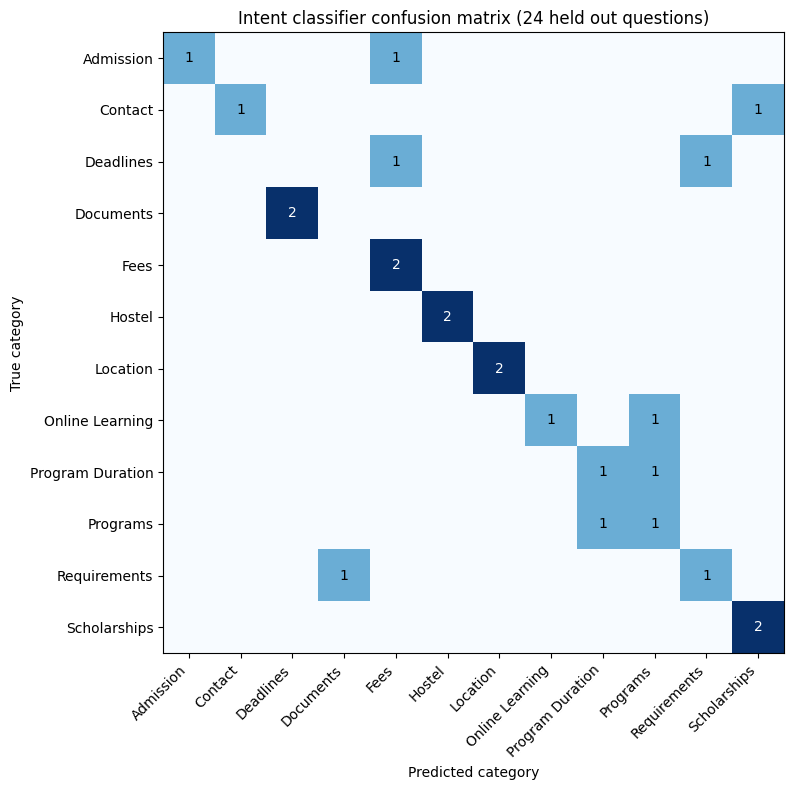

In [29]:
labels = sorted(intent_df["category"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
ax.set_title("Intent classifier confusion matrix (24 held out questions)")

for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > 1 else "black")

plt.tight_layout()
plt.show()

With only two test examples per class, one mistake moves a category from 100 percent to
50 percent. The per class numbers should therefore be read as an indication, not a
precise measurement. The overall accuracy across all 24 is the more stable figure.

In [30]:
faq_vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
faq_vectors = faq_vectorizer.fit_transform(faq_df["processed_question"])

print("FAQ retrieval matrix:", faq_vectors.shape)

FAQ retrieval matrix: (36, 111)


## 17. Cosine Similarity Inside the Predicted Category

In [31]:
def retrieve_within_category(processed_question, category):
    """Return the best FAQ row and its similarity, searching one category only."""
    subset = faq_df[faq_df["category"] == category]

    user_vector = faq_vectorizer.transform([processed_question])
    similarities = cosine_similarity(user_vector, faq_vectors[subset.index]).flatten()

    best_position = int(np.argmax(similarities))

    return subset.iloc[best_position], float(similarities[best_position])


def predict_intent(processed_question):
    """Return the category predicted by the trained classifier."""
    return intent_model.predict(intent_vectorizer.transform([processed_question]))[0]

In [32]:
demo = "What papers do I need to submit?"
processed = preprocess_text(demo)
category = predict_intent(processed)
row, score = retrieve_within_category(processed, category)

print("User question:     ", demo)
print("Predicted intent:  ", category)
print("Search space:      ", int((faq_df['category'] == category).sum()), "entries instead of", len(faq_df))
print("Matched FAQ:       ", row["question"])
print("Similarity:        ", round(score, 3))
print("Answer:            ", row["answer"])

User question:      What papers do I need to submit?
Predicted intent:   Documents
Search space:       3 entries instead of 36
Matched FAQ:        Which documents do I need to apply?
Similarity:         0.334
Answer:             You should provide your academic records, identification documents, and any additional documents required by the admission office.


In [33]:
def similarity_for(question):
    processed = preprocess_text(question)
    category = predict_intent(processed)
    _, score = retrieve_within_category(processed, category)
    return score


in_domain_scores = [similarity_for(q) for q in X_test]

out_of_domain_questions = [
    "How do I cook chicken biryani?",
    "What is the weather today?",
    "Who won the football match last night?",
    "Tell me a joke about cats.",
    "How do I change a car tyre?",
    "What is the capital of Japan?",
    "How do I train a neural network?",
    "Give me a recipe for pasta.",
    "What time does the cinema open?",
    "How tall is Mount Everest?",
    "Can you write a poem about rain?",
    "What is the price of bitcoin?",
    "How do I fix a leaking tap?",
    "Which airline flies to Dubai?",
    "What is the best phone to buy?",
]
out_of_domain_scores = [similarity_for(q) for q in out_of_domain_questions]

print("In domain similarity     : min %.3f  median %.3f  max %.3f"
      % (np.min(in_domain_scores), np.median(in_domain_scores), np.max(in_domain_scores)))
print("Out of domain similarity : min %.3f  median %.3f  max %.3f"
      % (np.min(out_of_domain_scores), np.median(out_of_domain_scores), np.max(out_of_domain_scores)))

In domain similarity     : min 0.000  median 0.393  max 1.000
Out of domain similarity : min 0.000  median 0.000  max 0.000


In [34]:
sweep = []
for t in np.arange(0.00, 0.71, 0.05):
    accept_in = np.mean([s >= t for s in in_domain_scores])
    reject_out = np.mean([s < t for s in out_of_domain_scores])
    sweep.append({
        "threshold": round(float(t), 2),
        "accepted_in_domain_%": round(accept_in * 100, 1),
        "rejected_out_of_domain_%": round(reject_out * 100, 1),
        "balanced_%": round((accept_in + reject_out) / 2 * 100, 1),
    })

sweep_df = pd.DataFrame(sweep)
best_balanced = sweep_df["balanced_%"].max()
CONFIDENCE_THRESHOLD = float(sweep_df[sweep_df["balanced_%"] == best_balanced]["threshold"].max())

print("Chosen threshold:", CONFIDENCE_THRESHOLD)
sweep_df

Chosen threshold: 0.15


,threshold,accepted_in_domain_%,rejected_out_of_domain_%,balanced_%
0,0.00,100.0,0.0,50.0
1,0.05,87.5,100.0,93.8
2,0.10,87.5,100.0,93.8
3,0.15,87.5,100.0,93.8
4,0.20,83.3,100.0,91.7
5,0.25,75.0,100.0,87.5
6,0.30,70.8,100.0,85.4
7,0.35,62.5,100.0,81.2
8,0.40,45.8,100.0,72.9
9,0.45,37.5,100.0,68.8


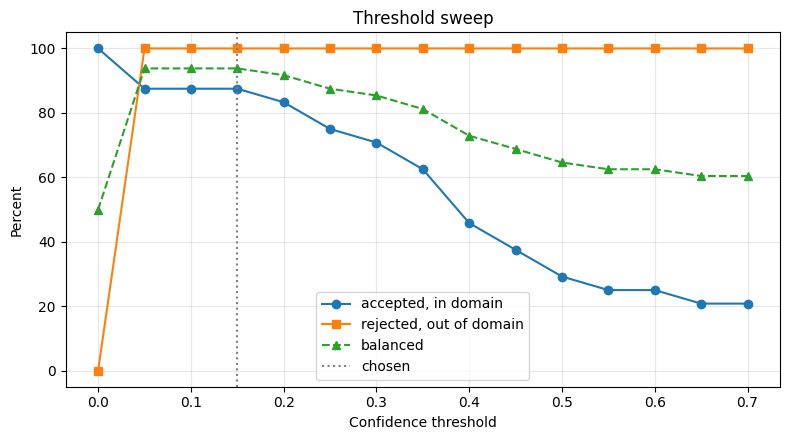

In [35]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep_df["threshold"], sweep_df["accepted_in_domain_%"], marker="o",
        label="accepted, in domain")
ax.plot(sweep_df["threshold"], sweep_df["rejected_out_of_domain_%"], marker="s",
        label="rejected, out of domain")
ax.plot(sweep_df["threshold"], sweep_df["balanced_%"], marker="^",
        linestyle="--", label="balanced")
ax.axvline(CONFIDENCE_THRESHOLD, color="grey", linestyle=":", label="chosen")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Percent")
ax.set_title("Threshold sweep")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
FALLBACK_MESSAGE = (
    "Sorry, I couldn't find a relevant answer to your question. "
    "Please try asking about admissions, programs, fees, scholarships, "
    "accommodation, deadlines, documents or contact details."
)


def chatbot_response(user_question):
    """Answer a user question using intent classification then restricted retrieval."""
    processed = preprocess_text(user_question)

    if not processed.strip():
        return {"status": "unknown", "intent": None, "matched_question": None,
                "similarity": 0.0, "answer": FALLBACK_MESSAGE}

    category = predict_intent(processed)
    row, score = retrieve_within_category(processed, category)

    if score >= CONFIDENCE_THRESHOLD:
        return {
            "status": "matched",
            "intent": category,
            "matched_question": row["question"],
            "similarity": round(score, 3),
            "answer": row["answer"],
        }

    return {
        "status": "unknown",
        "intent": None,
        "matched_question": None,
        "similarity": round(score, 3),
        "answer": FALLBACK_MESSAGE,
    }

In [37]:
for q in ["What documents do I need?", "How do I cook chicken biryani?"]:
    r = chatbot_response(q)
    print("Q:", q)
    for k, v in r.items():
        print(f"   {k:17s}: {v}")
    print()

Q: What documents do I need?
   status           : matched
   intent           : Documents
   matched_question : Which documents do I need to apply?
   similarity       : 0.791
   answer           : You should provide your academic records, identification documents, and any additional documents required by the admission office.

Q: How do I cook chicken biryani?
   status           : unknown
   intent           : None
   matched_question : None
   similarity       : 0.0
   answer           : Sorry, I couldn't find a relevant answer to your question. Please try asking about admissions, programs, fees, scholarships, accommodation, deadlines, documents or contact details.



In [38]:
training_pool = set(intent_df["question"].str.strip().str.lower()) | \
                set(faq_df["question"].str.strip().str.lower())

leaked = [q for q, _ in baseline_test_questions if q.strip().lower() in training_pool]

print(f"Baseline evaluation questions that also appear in training: "
      f"{len(leaked)} of {len(baseline_test_questions)}")
print()
for q in leaked[:6]:
    print("  -", q)
print("  ...")

Baseline evaluation questions that also appear in training: 19 of 24

  - What can I study at the university?
  - Which certificates do I need?
  - When should I submit my application?
  - How much time do I have to apply?
  - What qualifications do I need to get accepted?
  - Who is eligible to apply?
  ...


In [39]:
unseen_test_questions = [

    # Programs
    ("Tell me the list of degrees I could take here.", "Programs"),
    ("What areas of study does this institution teach?", "Programs"),

    # Admission
    ("I would like to become a student here, what is the first thing I do?", "Admission"),
    ("Please explain the joining process for new applicants.", "Admission"),

    # Documents
    ("Which files must be uploaded together with the form?", "Documents"),
    ("Do I have to send my transcripts and identity copies?", "Documents"),

    # Deadlines
    ("Has the closing date for this intake passed yet?", "Deadlines"),
    ("By what date must my application reach the office?", "Deadlines"),

    # Requirements
    ("What grades must a candidate hold before applying?", "Requirements"),
    ("Am I allowed to apply with my current qualifications?", "Requirements"),

    # Fees
    ("What is the price of one year of study?", "Fees"),
    ("Roughly what amount will the whole degree cost me?", "Fees"),

    # Scholarships
    ("Do you have any grants or bursaries for new students?", "Scholarships"),
    ("Is there a way to study with reduced financial burden?", "Scholarships"),

    # Contact
    ("Give me an email address or phone line for enquiries.", "Contact"),
    ("Who do I speak to about a question on my application?", "Contact"),

    # Location
    ("Which town or area is the campus built in?", "Location"),
    ("In which city is the main campus?", "Location"),

    # Hostel
    ("Do you have rooms on site for students from other cities?", "Hostel"),
    ("Is there a place for students to live near the campus?", "Hostel"),

    # Online Learning
    ("Could I follow the classes from my home city?", "Online Learning"),
    ("Do you run any courses over the internet?", "Online Learning"),

    # Program Duration
    ("How many semesters until I finish my degree?", "Program Duration"),
    ("What is the total length of time before graduation?", "Program Duration"),
]

print("Unseen evaluation questions:", len(unseen_test_questions))

Unseen evaluation questions: 24


In [40]:
overlap = [q for q, _ in unseen_test_questions if q.strip().lower() in training_pool]
print("Overlap with training data:", len(overlap), "questions")
assert len(overlap) == 0, "Evaluation set is contaminated"
print("Clean. Safe to evaluate on.")

Overlap with training data: 0 questions
Clean. Safe to evaluate on.


## 21. Final Evaluation

Both models are run on the same clean unseen set, so the comparison is fair.

In [41]:
rows = []
for question, expected in unseen_test_questions:
    processed = preprocess_text(question)

    base_idx, base_score = baseline_best_match(question)
    base_pred = faq_df.iloc[base_idx]["category"]

    hyb_pred = predict_intent(processed)
    hyb_row, hyb_score = retrieve_within_category(processed, hyb_pred)

    rows.append({
        "question": question,
        "expected": expected,
        "baseline_pred": base_pred,
        "baseline_ok": base_pred == expected,
        "hybrid_pred": hyb_pred,
        "hybrid_ok": hyb_pred == expected,
        "hybrid_sim": round(hyb_score, 3),
        "answered": hyb_score >= CONFIDENCE_THRESHOLD,
    })

final_results = pd.DataFrame(rows)

baseline_unseen_acc = final_results["baseline_ok"].mean()
hybrid_unseen_acc = final_results["hybrid_ok"].mean()

print(f"Baseline accuracy on clean unseen set : {baseline_unseen_acc * 100:.2f}%")
print(f"Hybrid accuracy on clean unseen set   : {hybrid_unseen_acc * 100:.2f}%")
print(f"Improvement                           : "
      f"{(hybrid_unseen_acc - baseline_unseen_acc) * 100:+.2f} points")

Baseline accuracy on clean unseen set : 41.67%
Hybrid accuracy on clean unseen set   : 62.50%
Improvement                           : +20.83 points


In [42]:
final_results[["question", "expected", "baseline_pred", "hybrid_pred", "hybrid_sim", "hybrid_ok"]]

,question,expected,baseline_pred,hybrid_pred,hybrid_sim,hybrid_ok
0,Tell me the list of degrees I could take here.,Programs,Program Duration,Program Duration,0.568,False
1,What areas of study does this institution teach?,Programs,Online Learning,Programs,0.000,True
2,"I would like to become a student here, what is the first thing I do?",Admission,Hostel,Hostel,0.399,False
3,Please explain the joining process for new applicants.,Admission,Programs,Admission,0.000,True
4,Which files must be uploaded together with the form?,Documents,Programs,Documents,0.000,True
5,Do I have to send my transcripts and identity copies?,Documents,Hostel,Hostel,0.496,False
6,Has the closing date for this intake passed yet?,Deadlines,Deadlines,Deadlines,0.462,True
7,By what date must my application reach the office?,Deadlines,Contact,Deadlines,0.287,True
8,What grades must a candidate hold before applying?,Requirements,Programs,Documents,0.000,False
9,Am I allowed to apply with my current qualifications?,Requirements,Requirements,Requirements,0.400,True


### 21.1 FAQ retrieval accuracy

Intent accuracy is not the whole story. The user sees an answer, not a category, so
retrieval accuracy is measured separately: did the returned answer belong to the right
category, after the threshold was applied.

In [43]:
retrieval_correct = final_results["hybrid_ok"] & final_results["answered"]
answered_rate = final_results["answered"].mean()

print(f"Questions answered rather than rejected: {answered_rate * 100:.2f}%")
print(f"Answered and correct (end to end)      : {retrieval_correct.mean() * 100:.2f}%")
print(f"Answered but wrong                     : "
      f"{(final_results['answered'] & ~final_results['hybrid_ok']).mean() * 100:.2f}%")
print(f"Rejected (no answer given)             : "
      f"{(~final_results['answered']).mean() * 100:.2f}%")

Questions answered rather than rejected: 70.83%
Answered and correct (end to end)      : 45.83%
Answered but wrong                     : 25.00%
Rejected (no answer given)             : 29.17%


In [44]:
print("Accuracy by category on the clean unseen set:\n")
by_cat = final_results.groupby("expected").agg(
    tested=("hybrid_ok", "count"),
    baseline_correct=("baseline_ok", "sum"),
    hybrid_correct=("hybrid_ok", "sum"),
)
by_cat["baseline_%"] = (by_cat["baseline_correct"] / by_cat["tested"] * 100).round(1)
by_cat["hybrid_%"] = (by_cat["hybrid_correct"] / by_cat["tested"] * 100).round(1)
by_cat[["tested", "baseline_%", "hybrid_%"]]

Accuracy by category on the clean unseen set:



,tested,baseline_%,hybrid_%
expected,,,
Admission,2,0.0,50.0
Contact,2,0.0,0.0
Deadlines,2,50.0,100.0
Documents,2,0.0,50.0
Fees,2,50.0,0.0
Hostel,2,100.0,100.0
Location,2,100.0,100.0
Online Learning,2,100.0,100.0
Program Duration,2,50.0,100.0


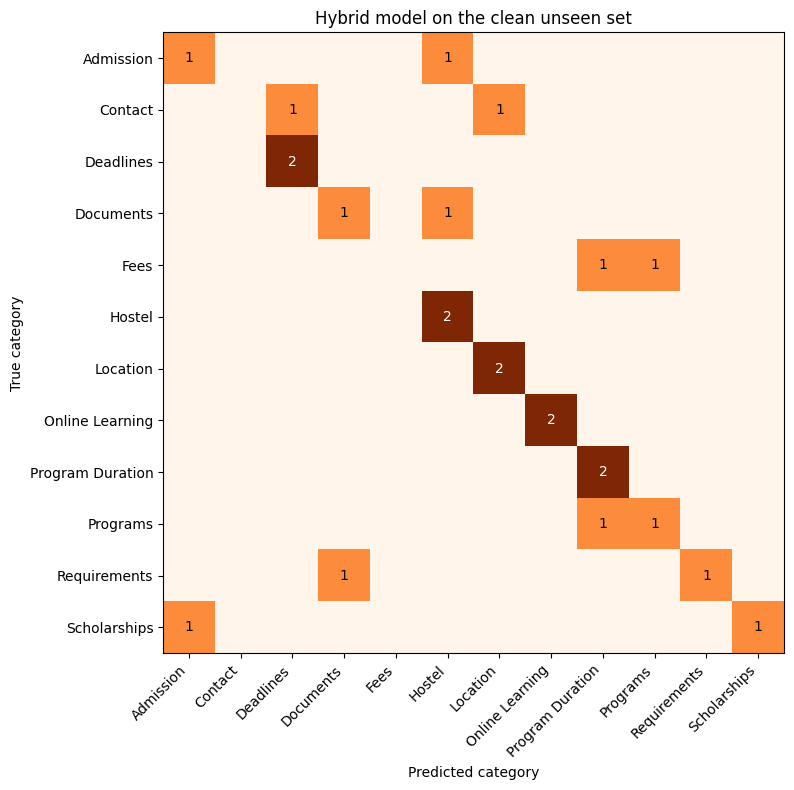

In [45]:
labels_u = sorted(final_results["expected"].unique())
cm_u = confusion_matrix(final_results["expected"], final_results["hybrid_pred"], labels=labels_u)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(cm_u, cmap="Oranges")
ax.set_xticks(range(len(labels_u)))
ax.set_yticks(range(len(labels_u)))
ax.set_xticklabels(labels_u, rotation=45, ha="right")
ax.set_yticklabels(labels_u)
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
ax.set_title("Hybrid model on the clean unseen set")
for i in range(len(labels_u)):
    for j in range(len(labels_u)):
        if cm_u[i, j]:
            ax.text(j, i, cm_u[i, j], ha="center", va="center",
                    color="white" if cm_u[i, j] > 1 else "black")
plt.tight_layout()
plt.show()

## 22. Error Analysis

Every wrong prediction is listed. None are hidden.

In [46]:
errors = final_results[~final_results["hybrid_ok"]][
    ["question", "expected", "hybrid_pred", "hybrid_sim"]
]
print("Incorrect predictions:", len(errors), "of", len(final_results))
errors

Incorrect predictions: 9 of 24


,question,expected,hybrid_pred,hybrid_sim
0,Tell me the list of degrees I could take here.,Programs,Program Duration,0.568
2,"I would like to become a student here, what is the first thing I do?",Admission,Hostel,0.399
5,Do I have to send my transcripts and identity copies?,Documents,Hostel,0.496
8,What grades must a candidate hold before applying?,Requirements,Documents,0.000
10,What is the price of one year of study?,Fees,Programs,0.000
11,Roughly what amount will the whole degree cost me?,Fees,Program Duration,0.253
12,Do you have any grants or bursaries for new students?,Scholarships,Admission,0.000
14,Give me an email address or phone line for enquiries.,Contact,Location,0.666
15,Who do I speak to about a question on my application?,Contact,Deadlines,0.535


In [47]:
print("What each failing question looks like after preprocessing:\n")
for q in errors["question"]:
    print(f"  {preprocess_text(q)}")

What each failing question looks like after preprocessing:

  tell me list degree take here
  like become student here first thing
  have send transcript identity copy
  grade must candidate hold before applying
  price one year study
  roughly amount will whole degree cost me
  have any grant bursary new student
  give me email address phone line enquiry
  speak question application


In [48]:
comparison = pd.DataFrame([
    {
        "model": "Baseline: TF-IDF + cosine over 36 FAQs",
        "evaluation set": "24 paraphrases (original)",
        "accuracy_%": round(baseline_accuracy * 100, 2),
    },
    {
        "model": "Baseline: TF-IDF + cosine over 36 FAQs",
        "evaluation set": "24 paraphrases (clean, unseen)",
        "accuracy_%": round(baseline_unseen_acc * 100, 2),
    },
    {
        "model": "Improved hybrid: TF-IDF + LogReg intent + restricted cosine + threshold",
        "evaluation set": "24 held out from the 120 split",
        "accuracy_%": round(intent_accuracy * 100, 2),
    },
    {
        "model": "Improved hybrid: TF-IDF + LogReg intent + restricted cosine + threshold",
        "evaluation set": "24 paraphrases (clean, unseen)",
        "accuracy_%": round(hybrid_unseen_acc * 100, 2),
    },
])
comparison

,model,evaluation set,accuracy_%
0,Baseline: TF-IDF + cosine over 36 FAQs,24 paraphrases (original),41.67
1,Baseline: TF-IDF + cosine over 36 FAQs,"24 paraphrases (clean, unseen)",41.67
2,Improved hybrid: TF-IDF + LogReg intent + restricted cosine + thre...,24 held out from the 120 split,58.33
3,Improved hybrid: TF-IDF + LogReg intent + restricted cosine + thre...,"24 paraphrases (clean, unseen)",62.50


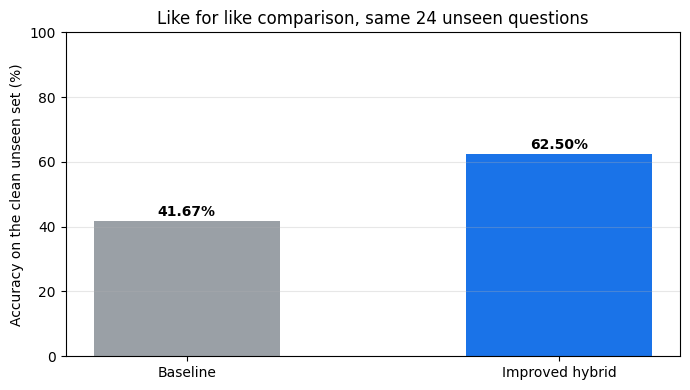

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
names = ["Baseline", "Improved hybrid"]
values = [baseline_unseen_acc * 100, hybrid_unseen_acc * 100]
bars = ax.bar(names, values, color=["#9aa0a6", "#1a73e8"], width=0.5)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.2f}%",
            ha="center", fontweight="bold")
ax.set_ylim(0, 100)
ax.set_ylabel("Accuracy on the clean unseen set (%)")
ax.set_title("Like for like comparison, same 24 unseen questions")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
def show(question):
    r = chatbot_response(question)
    print("User :", question)
    if r["status"] == "matched":
        print(f"Bot  : {r['answer']}")
        print(f"       [intent: {r['intent']} | matched: \"{r['matched_question']}\" "
              f"| confidence: {r['similarity']}]")
    else:
        print(f"Bot  : {r['answer']}")
        print(f"       [rejected | best score {r['similarity']} < threshold {CONFIDENCE_THRESHOLD}]")
    print("-" * 100)


print("SUCCESSFUL QUERIES\n")
for q in [
    "How much is the tuition fee?",
    "Which documents do I need to apply?",
    "Can I study online?",
    "Is accommodation available for students?",
    "When is the last date to apply?",
]:
    show(q)

SUCCESSFUL QUERIES

User : How much is the tuition fee?
Bot  : Tuition fees depend on the degree program and university fee structure.
       [intent: Fees | matched: "How much is the tuition fee?" | confidence: 1.0]
----------------------------------------------------------------------------------------------------
User : Which documents do I need to apply?
Bot  : You should provide your academic records, identification documents, and any additional documents required by the admission office.
       [intent: Documents | matched: "Which documents do I need to apply?" | confidence: 1.0]
----------------------------------------------------------------------------------------------------
User : Can I study online?
Bot  : Whether you can study online depends on the program and university policies.
       [intent: Online Learning | matched: "Can I study online?" | confidence: 1.0]
----------------------------------------------------------------------------------------------------
User : Is 

In [51]:
print("REJECTED QUERIES\n")
for q in [
    "How do I cook chicken biryani?",
    "Who won the football match last night?",
    "What is the capital of Japan?",
    "Can you write me a poem?",
]:
    show(q)

REJECTED QUERIES

User : How do I cook chicken biryani?
Bot  : Sorry, I couldn't find a relevant answer to your question. Please try asking about admissions, programs, fees, scholarships, accommodation, deadlines, documents or contact details.
       [rejected | best score 0.0 < threshold 0.15]
----------------------------------------------------------------------------------------------------
User : Who won the football match last night?
Bot  : Sorry, I couldn't find a relevant answer to your question. Please try asking about admissions, programs, fees, scholarships, accommodation, deadlines, documents or contact details.
       [rejected | best score 0.0 < threshold 0.15]
----------------------------------------------------------------------------------------------------
User : What is the capital of Japan?
Bot  : Sorry, I couldn't find a relevant answer to your question. Please try asking about admissions, programs, fees, scholarships, accommodation, deadlines, documents or contact 

In [52]:
print("QUERIES THE MODEL GETS WRONG\n")
for q in errors["question"].head(3):
    show(q)

QUERIES THE MODEL GETS WRONG

User : Tell me the list of degrees I could take here.
Bot  : Bachelor's degree duration varies according to the program and institution.
       [intent: Program Duration | matched: "How many years does a bachelor's degree take?" | confidence: 0.568]
----------------------------------------------------------------------------------------------------
User : I would like to become a student here, what is the first thing I do?
Bot  : Student accommodation may be provided depending on availability and university policy.
       [intent: Hostel | matched: "Is accommodation available for students?" | confidence: 0.399]
----------------------------------------------------------------------------------------------------
User : Do I have to send my transcripts and identity copies?
Bot  : Hostel or student accommodation may be available depending on the university and campus.
       [intent: Hostel | matched: "Does the university have a hostel?" | confidence: 0.496]
-

In [53]:
NOTEBOOK_IN_SUBFOLDER = Path.cwd().name in {"notebooks", "notebook"}
ROOT = Path("..") if NOTEBOOK_IN_SUBFOLDER else Path(".")

MODEL_DIR = ROOT / "models"
DATA_DIR = ROOT / "data"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(intent_model, MODEL_DIR / "intent_model.pkl")
joblib.dump(intent_vectorizer, MODEL_DIR / "intent_vectorizer.pkl")
joblib.dump(faq_vectorizer, MODEL_DIR / "faq_vectorizer.pkl")
joblib.dump(
    {
        "faq_df": faq_df[["question", "answer", "category", "processed_question"]],
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        "stop_words": stop_words,
        "fallback_message": FALLBACK_MESSAGE,
    },
    MODEL_DIR / "faq_data.pkl",
)

faq_df[["question", "answer", "category"]].to_csv(
    DATA_DIR / "university_faqs.csv", index=False
)
intent_df[["question", "category"]].to_csv(
    DATA_DIR / "intent_training_data.csv", index=False
)

for path in sorted(MODEL_DIR.glob("*.pkl")) + sorted(DATA_DIR.glob("*.csv")):
    print(f"  saved {path}  ({path.stat().st_size / 1024:.1f} KB)")

  saved ../models/faq_data.pkl  (8.3 KB)
  saved ../models/faq_vectorizer.pkl  (3.4 KB)
  saved ../models/intent_model.pkl  (32.9 KB)
  saved ../models/intent_vectorizer.pkl  (7.6 KB)
  saved ../data/intent_training_data.csv  (5.7 KB)
  saved ../data/university_faqs.csv  (4.9 KB)


In [54]:
# Verify the saved artefacts reload and behave identically
loaded_model = joblib.load(MODEL_DIR / "intent_model.pkl")
loaded_intent_vec = joblib.load(MODEL_DIR / "intent_vectorizer.pkl")
loaded_bundle = joblib.load(MODEL_DIR / "faq_data.pkl")

check = "What are the tuition charges?"
reloaded_pred = loaded_model.predict(loaded_intent_vec.transform([preprocess_text(check)]))[0]

print("Question:          ", check)
print("In memory model:   ", predict_intent(preprocess_text(check)))
print("Reloaded model:    ", reloaded_pred)
print("Threshold restored:", loaded_bundle["confidence_threshold"])
print("FAQ rows restored: ", len(loaded_bundle["faq_df"]))
print("\nArtefacts verified.")

Question:           What are the tuition charges?
In memory model:    Fees
Reloaded model:     Fees
Threshold restored: 0.15
FAQ rows restored:  36

Artefacts verified.
